# はじめに

このノートでは時系列系の処理を行うライブラリをPythonで利用する方法をまとめておく。説明も特にない。時系列分析に関する数理的な要素や分析の正当性については、ここでは扱わない。

## 道具立て

必要なライブラリとデータの準備をしておく。時系列のデータは、昔運用していたブログのGAアクセスデータを利用する。期間は、2016-08-01~2019-06-30の2年半。

In [551]:
# load library
import numpy as np
import pandas as pd 
from typing import Union
from tqdm import tqdm_notebook
from itertools import product
import ipywidgets
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import MSTL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox


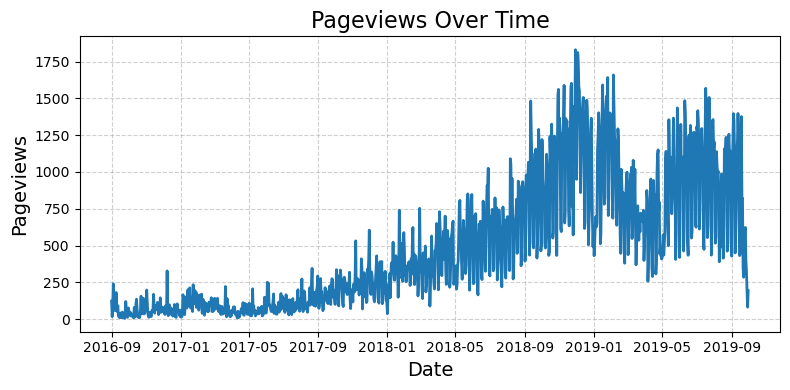

In [477]:
df=pd.read_csv('./data/GoogleAnalytics_TimeSeriesData.csv')
df=df[['date', 'pageviews']]
df['date']=pd.to_datetime(df['date'])
df=df.sort_values('date')

plt.figure(figsize=(8, 4))
plt.plot(df['date'], df['pageviews'], linewidth=2)
plt.title('Pageviews Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Pageviews', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 時系列の性質
### STL分解

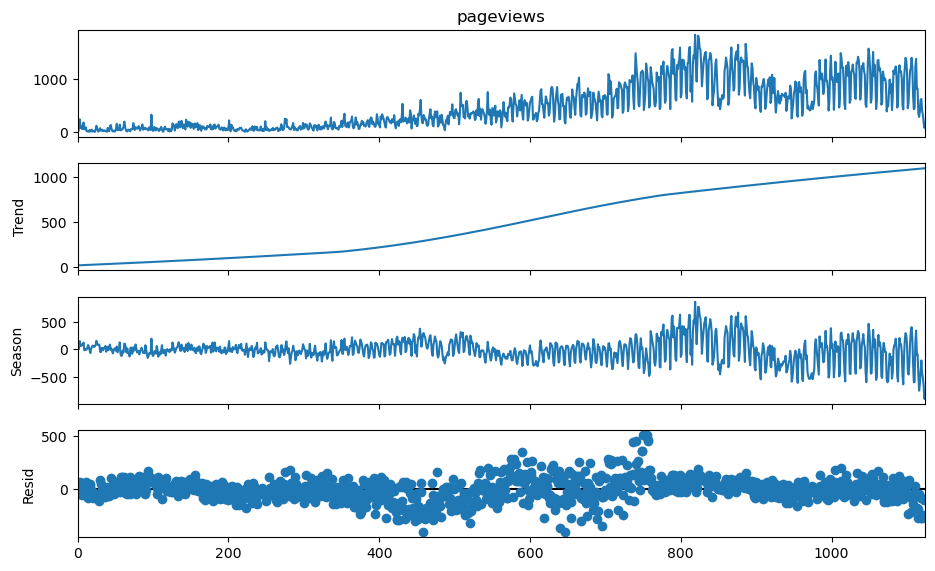

In [478]:
stl=STL(df['pageviews'], period=365)
res=stl.fit()
res.plot()
plt.gcf().set_size_inches(10, 6)

#### MSTL分解

STL分解で複数の季節性周期が存在する場合、MSTL分解を利用できる。残差が0っぽい部分があるが、ここではスルーする。

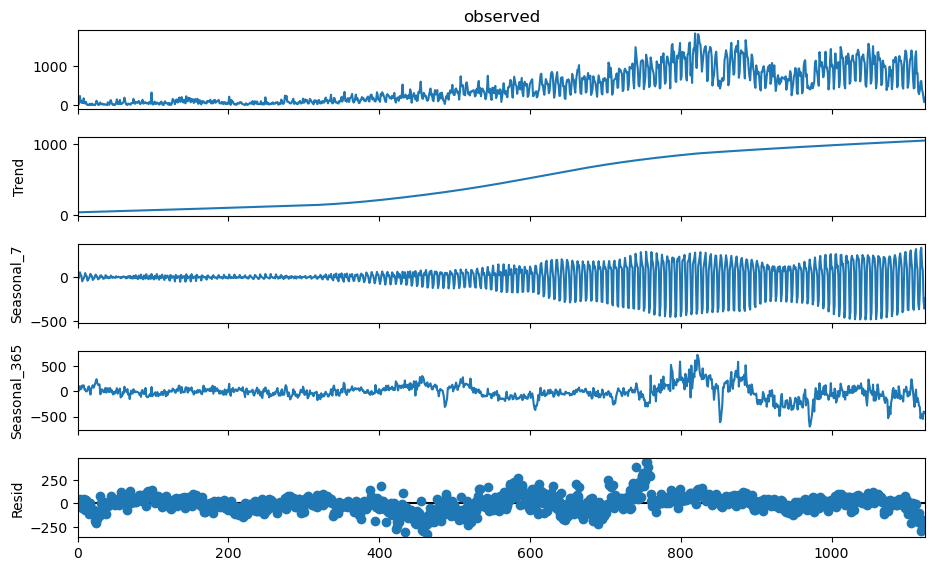

In [479]:
mstl=MSTL(df['pageviews'], periods=[365, 7])
res=mstl.fit()
res.plot()
plt.gcf().set_size_inches(10, 6)

### 自己相関&偏自己相関

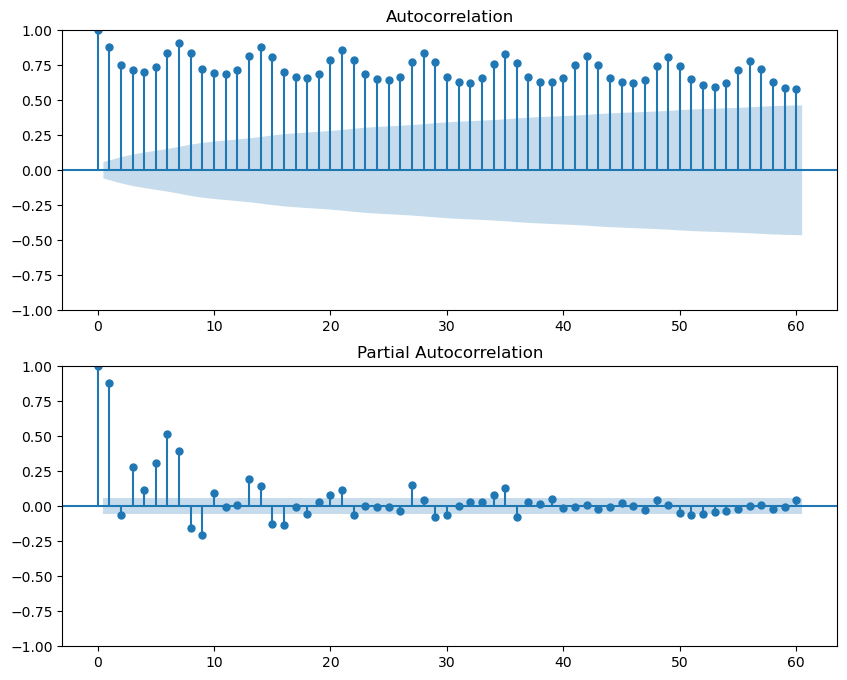

In [480]:
fig, ax=plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df['pageviews'], ax = ax[0], lags=60)
plot_pacf(df['pageviews'], ax = ax[1], lags=60)
plt.show()

### 定常性（ADF検定）

- H0: データは非定常（単位根が存在）
- H1: データは定常（単位根が存在しない）

In [481]:
def adfuller_test(
  series, 
  signif=0.05,
  reg='c'
):
  result = adfuller(series, regression=reg)
  print(f'ADF Statistic: {result[0]}')
  print(f'p-value: {result[1]}')
  if result[1] <= signif:
    print("Series is stationary")
  else:
    print("Series is non-stationary")
    
adfuller_test(df['pageviews'])

ADF Statistic: -1.6539470834341925
p-value: 0.454982725176456
Series is non-stationary


### 差分系列

<Figure size 1000x400 with 0 Axes>

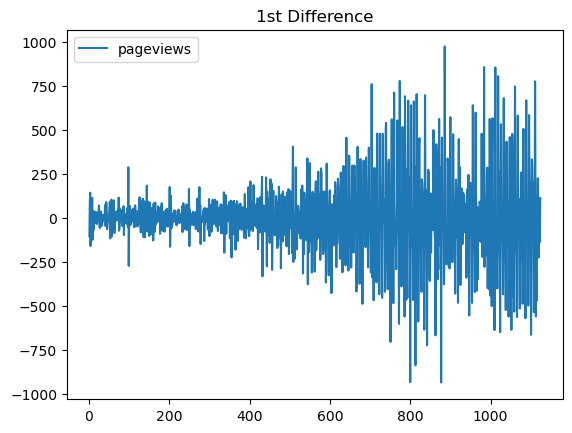

In [482]:
df_lag1 = df[['pageviews']].diff().dropna()
df_lag1.columns = ['pageviews']
plt.figure(figsize=(10, 4))
df_lag1.plot()
plt.title('1st Difference')
plt.show()

In [483]:
adfuller_test(df_lag1['pageviews'])

ADF Statistic: -8.59020514762287
p-value: 7.320930583609916e-14
Series is stationary


### 季節差分系列

週次なら`diff(7)`、月次なら`diff(30)`など

<Figure size 1000x400 with 0 Axes>

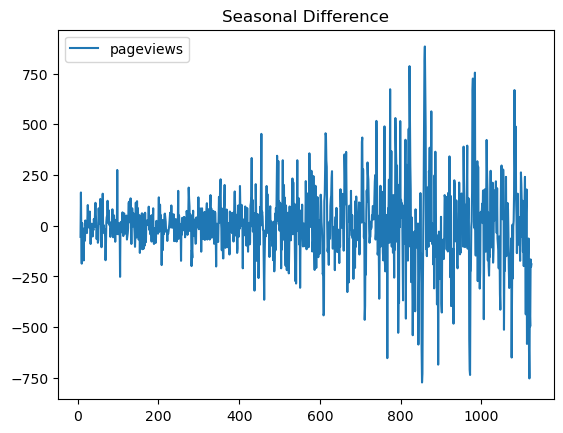

ADF Statistic: -7.418173167864041
p-value: 6.84713599947586e-11
Series is stationary


In [484]:
df_season7 = df[['pageviews']].diff(7).dropna()
df_season7.columns = ['pageviews']
plt.figure(figsize=(10, 4))
df_season7.plot()
plt.title('Seasonal Difference')
plt.show()
adfuller_test(df_season7['pageviews'])

### 対数系列

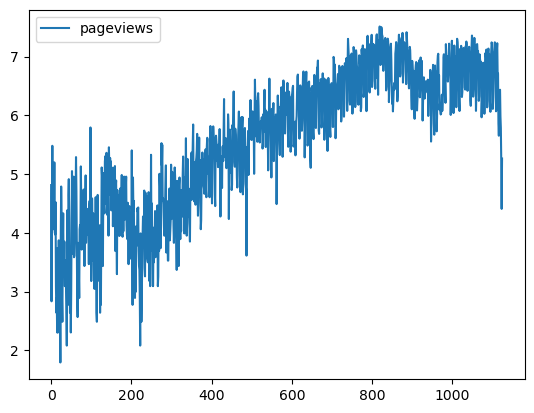

ADF Statistic: -1.989389997595561
p-value: 0.2912445048897185
Series is non-stationary


In [485]:
df_log=np.log(df[['pageviews']])
df_log.plot()
plt.show()
adfuller_test(df_log['pageviews'])

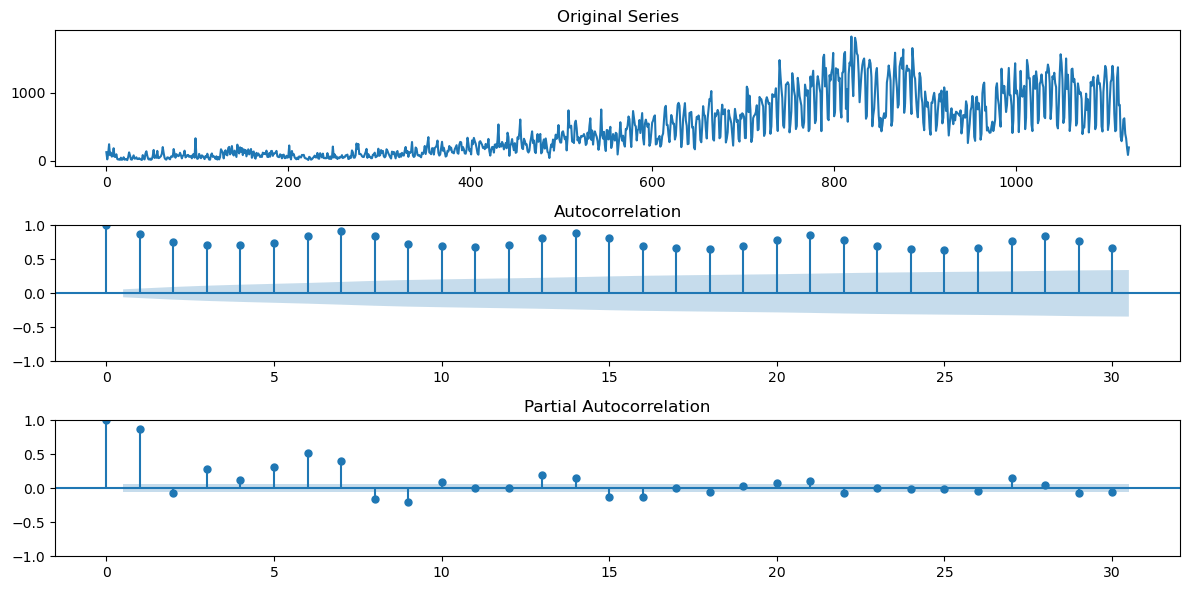

ADF Statistic: -1.6539470834341925
p-value: 0.454982725176456
Series is non-stationary


In [486]:
def plot_and_stationarity_test(
  series,
  title='',
):
  plt.figure(figsize=(12, 6))
  plt.subplot(311)
  plt.plot(series)
  plt.title(title)
  plt.subplot(312)
  plot_acf(series.dropna(), lags=30, ax=plt.gca())
  plt.subplot(313)
  plot_pacf(series.dropna(), lags=30, ax=plt.gca())
  plt.tight_layout()
  plt.show()
  adfuller_test(series.dropna())
  
plot_and_stationarity_test(df['pageviews'], title='Original Series')

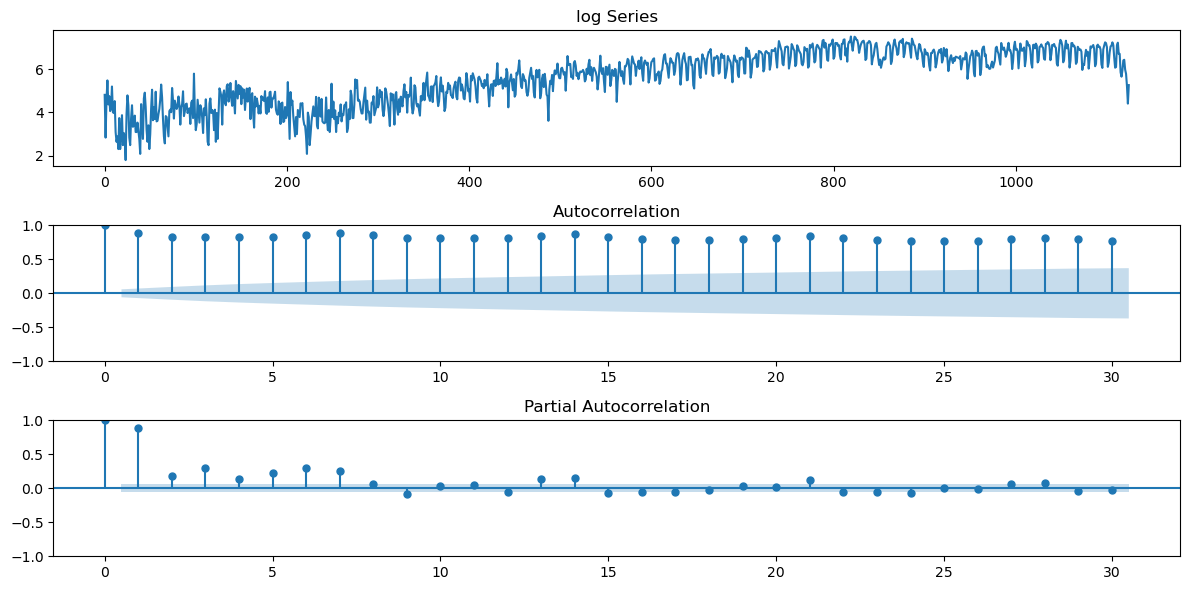

ADF Statistic: -1.989389997595561
p-value: 0.2912445048897185
Series is non-stationary


In [487]:
df_log=np.log(df[['pageviews']])
plot_and_stationarity_test(df_log, title='log Series')

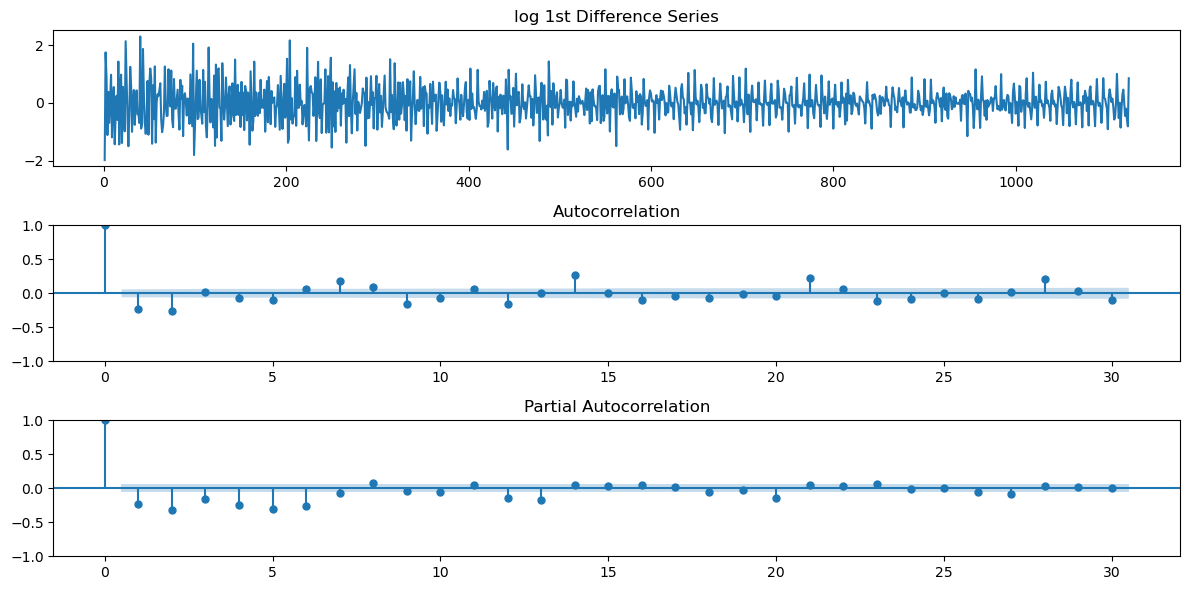

ADF Statistic: -12.13142953120872
p-value: 1.732307987017317e-22
Series is stationary


In [488]:
df_log_diff = df_log.diff()
plot_and_stationarity_test(df_log_diff, title='log 1st Difference Series')

## 時系列特徴量
### トレンド特徴量

In [489]:
df_tbl=df.copy()
df_tbl['t']=np.arange(len(df_tbl))
df_tbl

,date,pageviews,t
0,2016-09-01,123,0
1,2016-09-02,17,1
2,2016-09-03,98,2
3,2016-09-04,240,3
4,2016-09-05,79,4
...,...,...,...
1120,2019-09-26,396,1120
1121,2019-09-27,325,1121
1122,2019-09-28,184,1122
1123,2019-09-29,82,1123


### 三角関数特徴量

In [490]:
def fourier_features(df, num, seasonal, t_start=0):
  df_tbl=df.copy()
  t=np.arange(t_start, t_start+len(df_tbl))
  for i in range(1, num+1):
      df_tbl[f'sin_{i}']=np.sin(2*np.pi*i*t/seasonal)
      df_tbl[f'cos_{i}']=np.cos(2*np.pi*i*t/seasonal)
  return df_tbl

fourier_features(df, 3, 365)

,date,pageviews,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
0,2016-09-01,123,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,2016-09-02,17,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667
2,2016-09-03,98,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671
3,2016-09-04,240,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023
4,2016-09-05,79,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740
...,...,...,...,...,...,...,...,...
1120,2019-09-26,396,0.417194,0.908818,0.758306,0.651899,0.961130,0.276097
1121,2019-09-27,325,0.432776,0.901502,0.780296,0.625411,0.974100,0.226116
1122,2019-09-28,184,0.448229,0.893919,0.801361,0.598181,0.984474,0.175531
1123,2019-09-29,82,0.463550,0.886071,0.821477,0.570242,0.992222,0.124479


### ラグ特徴量

In [491]:
df_tbl=df.copy()
df_tbl['lag1']=df_tbl['pageviews'].shift(1)
df_tbl['lag12']=df_tbl['pageviews'].shift(12)
df_tbl.head(13)


,date,pageviews,lag1,lag12
0,2016-09-01,123,NaN,NaN
1,2016-09-02,17,123.0,NaN
2,2016-09-03,98,17.0,NaN
3,2016-09-04,240,98.0,NaN
4,2016-09-05,79,240.0,NaN
5,2016-09-06,116,79.0,NaN
6,2016-09-07,58,116.0,NaN
7,2016-09-08,68,58.0,NaN
8,2016-09-09,181,68.0,NaN
9,2016-09-10,55,181.0,NaN


### ローリング特徴量


In [492]:
df_tbl=df.copy()
df_tbl['lag1']=df_tbl['pageviews'].shift(1)
df_tbl['rm12']=df_tbl['lag1'].rolling(12).mean()
df_tbl['rm3']=df_tbl['lag1'].rolling(3).mean()
df_tbl.head(13)


,date,pageviews,lag1,rm12,rm3
0,2016-09-01,123,NaN,NaN,NaN
1,2016-09-02,17,123.0,NaN,NaN
2,2016-09-03,98,17.0,NaN,NaN
3,2016-09-04,240,98.0,NaN,79.333333
4,2016-09-05,79,240.0,NaN,118.333333
5,2016-09-06,116,79.0,NaN,139.000000
6,2016-09-07,58,116.0,NaN,145.000000
7,2016-09-08,68,58.0,NaN,84.333333
8,2016-09-09,181,68.0,NaN,80.666667
9,2016-09-10,55,181.0,NaN,102.333333


### エクスパンディング特徴量

In [493]:
df_tbl=df.copy()
df_tbl['lag1']=df_tbl['pageviews'].shift(1)
df_tbl['rm12']=df_tbl['lag1'].expanding().mean()
df_tbl.head(13)


,date,pageviews,lag1,rm12
0,2016-09-01,123,NaN,NaN
1,2016-09-02,17,123.0,123.000000
2,2016-09-03,98,17.0,70.000000
3,2016-09-04,240,98.0,79.333333
4,2016-09-05,79,240.0,119.500000
5,2016-09-06,116,79.0,111.400000
6,2016-09-07,58,116.0,112.166667
7,2016-09-08,68,58.0,104.428571
8,2016-09-09,181,68.0,99.875000
9,2016-09-10,55,181.0,108.888889


## SARIMA

最後に時系列モデルの基本ともいえるSARIMAモデルで時系列を予測してみる。SARIMAモデルの基本的なモデル構築の流れは、時系列を分解し、必要な差分の値を求める。そして、パラメタをチューニングし、残差分析。モデルができたら予測する。

In [494]:
# 1. データの読み込み
df_all=pd.read_csv('./data/GoogleAnalytics_TimeSeriesData.csv')
df_all=df_all[['date', 'pageviews']].rename(columns={'date': 'ds', 'pageviews': 'y'})
df_all['ds'] = pd.to_datetime(df_all['ds'])
# 予測精度を高めるために不要なレコードを削除
df=df_all[df_all['ds'] >= '2018-07-01']    
df.head()

,ds,y
668,2018-07-01,294
669,2018-07-02,697
670,2018-07-03,652
671,2018-07-04,688
672,2018-07-05,746


時系列分解すると、トレンドと周期が存在していることがわかる。

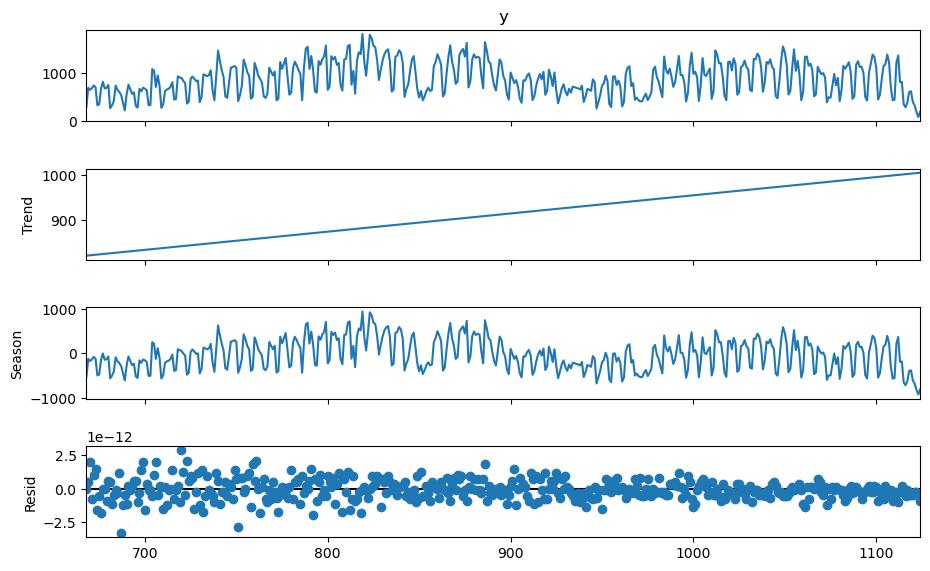

In [497]:
stl=STL(df['y'], period=365)
res=stl.fit()
res.plot()
plt.gcf().set_size_inches(10, 6)

データはトレンドと週周期性を持っていたので、1階差分だけでは周期性が残るため、週差分（ラグ7）が有効。1階差分＋週差分後は、ほぼホワイトノイズに近いことがわかる。処理後のデータは定常であることもわかる。そのため、今回のSARIMAモデルの`d,D,m`は`d=1,D=1,m=7`を利用する。

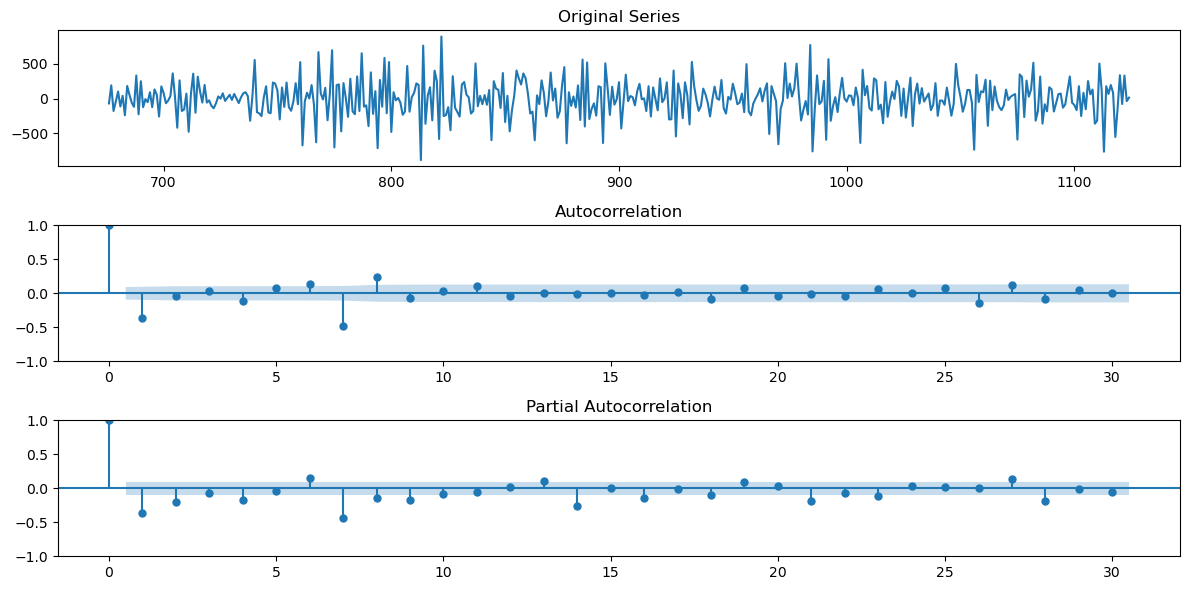

ADF Statistic: -7.037656816132178
p-value: 5.958351192386555e-10
Series is stationary


In [495]:
plot_and_stationarity_test(df['y'].diff().diff(7).dropna(), title='Original Series')

In [569]:
train = df.y[df['ds'] < '2019-09-01']
test=df.y[df['ds'] >= '2019-09-01']
len(train), len(test)

(427, 30)

1095     428
1096    1011
1097    1203
1098    1396
1099    1346
1100    1116
1101     450
1102     551
1103     883
1104    1157
1105    1197
1106    1397
1107    1228
1108     691
1109     432
1110     446
1111    1221
1112    1376
1113     814
1114     821
1115     350
1116     285
1117     383
1118     607
1119     623
1120     396
1121     325
1122     184
1123      82
1124     193
Name: y, dtype: int64

データ分割が完了したので、AICが最小になるモデルを特定するための作業を行う。

In [ ]:
ps=range(0,3,1)
qs=range(0,3,1)
Ps=range(0,3,1)
Qs=range(0,3,1)
order_list=list(product(ps,qs,Ps,Qs))

d=1
D=1
s=7

def optimize_SARIMAX(
    train: Union[pd.Series, list],
    regs: Union[pd.Series, list],
    order_list: list,
    d: int,
    D: int,
    s: int
    ) -> pd.DataFrame:
    
    results = []
    
    for order in order_list:
        try: 
            model = SARIMAX(
                train,
                regs,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [ ]:
result_df = optimize_SARIMAX(train, None, order_list, d, D, s)

AICが最も小さい組み合わせは、`p=1,q=3,P=3,Q=4`とわかる。最適なモデルがわかったので、残差分析を行い、予測モデルとして利用できるかを調べる。

In [546]:
result_df

,"(p,q,P,Q)",AIC
0,"(1, 3, 3, 4)",24.000000
1,"(1, 3, 4, 4)",26.000000
2,"(2, 4, 4, 3)",28.000000
3,"(3, 4, 4, 3)",91.443520
4,"(1, 1, 0, 1)",5522.805320
...,...,...
617,"(4, 0, 0, 0)",5780.131734
618,"(2, 0, 0, 0)",5788.605527
619,"(3, 0, 0, 0)",5789.638608
620,"(1, 0, 0, 0)",5801.439112


残差分析の結果がこちら。左上のプロットではトレンドもなく、分散も一定。右上の分布は正規分布に近い。左下のqqプロットも問題ない。コレログラムも自己相関も特に発生していない。

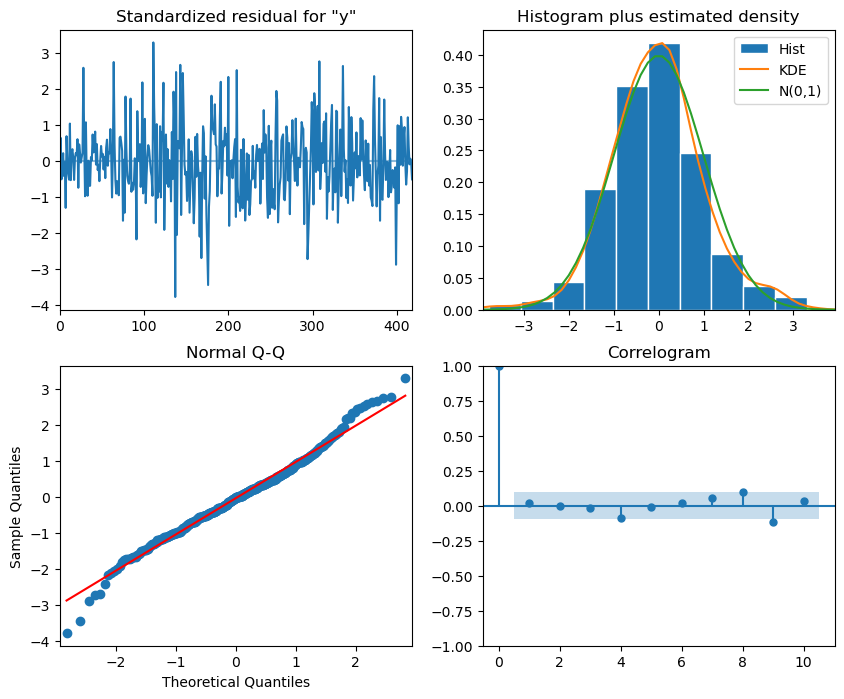

In [ ]:
model=SARIMAX(train, order=(1,1,3), seasonal_order=(3,1,4,7), simple_differencing=False)
model_fit=model.fit(disp=False)
plt=model_fit.plot_diagnostics(figsize=(10,8))


リュングボックス検定(帰無仮説は残差は無相関)の結果を見ると、すべて有意ではないので、残差は無相関とわかる。

In [562]:
resid=model_fit.resid
acorr_ljungbox(resid, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,0.282332,0.595177
2,0.290347,0.864872
3,0.393779,0.941525
4,2.832898,0.586167
5,3.021549,0.696663
6,3.026453,0.805519
7,4.063801,0.772400
8,8.830372,0.356807
9,13.824277,0.128715
10,14.112255,0.167933


予測モデルを使って予測する。ここでのテストデータは'2019-09-01'以降の30日である。まず、学習データ全てを使って学習し直す。

In [611]:
full_model=SARIMAX(train, order=(1,1,3), seasonal_order=(3,1,4,7), simple_differencing=False)
full_model_fit = full_model.fit(disp=False)

print(full_model_fit.summary())

                                          SARIMAX Results                                           
Dep. Variable:                                            y   No. Observations:                  427
Model:             SARIMAX(1, 1, 3)x(3, 1, [1, 2, 3, 4], 7)   Log Likelihood                   0.000
Date:                                         土, 09  8 2025   AIC                             24.000
Time:                                              02:21:25   BIC                             72.454
Sample:                                                   0   HQIC                            43.153
                                                      - 427                                         
Covariance Type:                                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   8.55e-08  

In [580]:
def rolling_forecast(
  df: pd.DataFrame,
  train_len: int,
  horizon: int,
  window: int) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len

    pred_SARIMA = []
    
    for i in range(train_len, total_len, window):
        model = SARIMAX(df['y'][:i], order=(2,1,3), seasonal_order=(1,1,2,7), simple_differencing=False)
        res = model.fit(disp=False)
        predictions = res.get_prediction(0, i + window - 1)
        oos_pred = predictions.predicted_mean.iloc[-window:]
        pred_SARIMA.extend(oos_pred)
        
    return pred_SARIMA

学習データは427で、テストデータは30レコードなので、データの先頭から427個の観測値を使って、初回のモデル学習を実施。最初の予測は 428番目のデータから始まる。
そして、学習終了時点から先の30個のテスト部分を予測。また、予測→実際の観測データ追加→再学習、という更新の間隔は1なので、1行づつこれを繰り返すことで予測する。

In [612]:
TRAIN_LEN = 427
HORIZON = 30
WINDOW = 1

pred_df = df[df['ds'] >= '2019-09-01'].copy()

# 予測値を取得
sarima_preds = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW)
sarima_preds = sarima_preds[:HORIZON]
pred_df['SARIMA'] = sarima_preds

In [613]:
pred_df

,ds,y,SARIMA
1095,2019-09-01,428,582.528058
1096,2019-09-02,1011,959.512334
1097,2019-09-03,1203,1099.531604
1098,2019-09-04,1396,1126.369320
1099,2019-09-05,1346,1234.783627
1100,2019-09-06,1116,1141.638930
1101,2019-09-07,450,665.647093
1102,2019-09-08,551,591.387735
1103,2019-09-09,883,1060.748176
1104,2019-09-10,1157,1099.923053


In [617]:
mean_absolute_error(
  pred_df[['y']], 
  pred_df[['SARIMA']]
  )
# oos_pred = full_model_fit.get_prediction(steps=HORIZON).predicted_mean
# mean_absolute_error(
#   pred_df[['y']], 
#   oos_pred[-HORIZON:]
#   )
# 448.50925521593194

188.77541148187174

In [616]:
# # テストデータ（2019-09-01以降）のさらに7日先まで予測する
# EXTEND_HORIZON = HORIZON + 7

# # 予測値を再計算
# sarima_preds_extended = rolling_forecast(df, TRAIN_LEN, EXTEND_HORIZON, WINDOW)
# sarima_preds_extended = sarima_preds_extended[:EXTEND_HORIZON]

# # 予測対象期間のデータフレームを作成  7日分日付を追加
# pred_df_extended = df[df['ds'] >= '2019-09-01'].copy()
# last_date = pd.to_datetime(pred_df_extended['ds'].iloc[-1])
# future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)
# future_df = pd.DataFrame({'ds': future_dates})
# pred_df_extended = pd.concat([pred_df_extended, future_df], ignore_index=True)
# pred_df_extended['SARIMA'] = sarima_preds_extended

# # 予測結果を表示
# pred_df_extended.tail(7)